In [1]:
"""SHARED FIGURE STYLE -- run first."""
import sys, pathlib


def _find_paper_style():
    here = pathlib.Path.cwd().resolve()
    for cand in [here, *here.parents]:
        if (cand / 'paper_style.py').exists():
            return cand
        if (cand / 'paper-individuality' / 'paper_style.py').exists():
            return cand / 'paper-individuality'
    raise FileNotFoundError(f'paper_style.py not found above {here}')


_root = _find_paper_style()
for _p in (str(_root), str(_root / 'learning_individuality')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
import paper_style as ps

ps.use('poster')

paper_style: poster mode, spines=lb, font 16 pt, panels 7.0x5.0 in, save 300 dpi


'poster'

In [2]:
"""
WHERE THE FOUR DATASETS SIT IN A MOUSE'S TRAINING
==================================================
A methods figure for the timepoints used by lda_sweep_timepoints and everything built
on it: Early, Late, Pre-rec and Proficient. It answers "how far apart are these, and
how consistent is that across animals?".

THE X AXIS IS SESSION NUMBER, counted from each mouse's first TASK session.

    Why it had to come from ONE. The per-mouse trials tables
    (data/training/training_data/) cover only the basic training protocol: Early is in
    them, but Late appears in 1 of 58, and Pre-rec and Proficient in none. Counting
    sessions across the whole history therefore needs the full session list per
    subject, which is what session_ordinals_task.parquet caches (~1 min over 58 mice).

    Why habituation is dropped. ONE lists habituationChoiceWorld sessions before the
    first training session, which pushed "Early" to a median ordinal of 4 even though
    it is by definition the first training session. Counting only training / biased /
    ephys sessions puts Early back at 1 (max 2), which is what it should be.

WHAT THE FIGURE IS FOR. The timepoints are defined by TRAINING STAGE, not by elapsed
time, and mice differ enormously in how long they take. One animal's Late can fall
later than another's Proficient. The population panel makes that overlap explicit
rather than leaving it implied by a schematic with four evenly spaced ticks.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import importlib, session_filters
importlib.reload(session_filters)
from session_filters import load_session_table

# ------------------------------------------------------------------ parameters
N_MICE = 12                 # example mice in the trajectory panel
SPAN_SELECTION = True      # True: span fastest -> slowest. False: first N alphabetically
SHOW_LEARNING_CURVE = True # adds the performance panel (basic-training sessions only)
ORDER = ['Early', 'Late', 'Pre-rec', 'Proficient']
COLORS = {t: ps.TIMEPOINT[t] for t in ORDER}
LABELS = {t: ps.TIMEPOINT_LABEL[t] for t in ORDER}

In [3]:
""" LOAD -- the cached session list, re-indexed over task sessions only. """
TASK = pd.read_parquet('session_ordinals_task.parquet')
TAB = load_session_table().drop_duplicates('eid').dropna(subset=['mouse_name', 'timepoint'])

MARK = TAB.merge(TASK[['eid', 'mouse_name', 'train_ord', 'kind']],
                 on=['eid', 'mouse_name'], how='left').dropna(subset=['train_ord'])
MARK['train_ord'] = MARK['train_ord'].astype(int)

# PL034 is dropped here for the same reason lda_pred and wheel_velocity_timepoints
# drop it (`lda.loc[lda['mouse_name'] != 'PL034']`): its cached trials table holds a
# single session, so it has no learning curve to draw and its record looks incomplete.
EXCLUDE_MICE = ['PL034']
TASK = TASK.loc[~TASK['mouse_name'].isin(EXCLUDE_MICE)]
MARK = MARK.loc[~MARK['mouse_name'].isin(EXCLUDE_MICE)]

n_last = TASK.groupby('mouse_name')['train_ord'].max()
have_all = MARK.groupby('mouse_name')['timepoint'].nunique()
COHORT = sorted(have_all[have_all == len(ORDER)].index)
print(f'{len(COHORT)} mice with all four timepoints placed on a session axis')
print(f'total task sessions per mouse: median {int(n_last[COHORT].median())}, '
      f'range {int(n_last[COHORT].min())}-{int(n_last[COHORT].max())}')
print('\nsession number of each dataset:')
print(MARK[MARK.mouse_name.isin(COHORT)].groupby('timepoint')['train_ord']
      .describe()[['count', 'min', '25%', '50%', '75%', 'max']].round(0)
      .reindex(ORDER).to_string())

# example mice, spanning the range of training length rather than picked arbitrarily
# When the learning-curve panel is on, restrict the spanning selection to mice that
# HAVE enough cached trial sessions to draw one. The timeline panels work for every
# mouse (they come from ONE), but a spanning pick that lands on NYU-37 (no trials
# table at all -- the only such mouse) or PL034 (one session) yields an empty panel.
MIN_CURVE_SESSIONS = 5
if SHOW_LEARNING_CURVE:
    _TTD = next((d for d in [_root / 'data' / 'training' / 'training_data',
                             pathlib.Path('/Users/ineslaranjeira/Google Drive/O meu disco/'
                                          'CCU/PhD Project/paper-individuality/data/'
                                          'training/training_data (1)')] if d.is_dir()), None)

    def _n_curve(mouse):
        f = (_TTD / f'training_data_trials_{mouse}') if _TTD else None
        if f is None or not f.exists():
            return 0
        t = pd.read_parquet(f, columns=['session', 'contrastLeft', 'contrastRight'])
        t['absc'] = t[['contrastLeft', 'contrastRight']].fillna(0).max(axis=1)
        return int((t.loc[t['absc'] >= 0.5].groupby('session').size() >= 20).sum())

    _ok = [m for m in COHORT if _n_curve(m) >= MIN_CURVE_SESSIONS]
    _dropped = sorted(set(COHORT) - set(_ok))
    print(f'\n{len(_dropped)} mice excluded from the EXAMPLE selection for having '
          f'< {MIN_CURVE_SESSIONS} cached curve sessions: {_dropped}')
    print('  (they stay in the cohort panels, which need no trial data)')
    SELECT_FROM = _ok
else:
    SELECT_FROM = COHORT

if SPAN_SELECTION:
    ranked = n_last[SELECT_FROM].sort_values()
    idx = np.linspace(0, len(ranked) - 1, N_MICE).round().astype(int)
    EXAMPLES = list(ranked.index[idx])
else:
    EXAMPLES = SELECT_FROM[:N_MICE]
print(f'\nexample mice ({N_MICE}), fastest -> slowest:')
for m in EXAMPLES:
    print(f'  {m:14s} {int(n_last[m]):3d} sessions')

57 mice with all four timepoints placed on a session axis
total task sessions per mouse: median 56, range 26-152

session number of each dataset:
            count   min   25%   50%   75%    max
timepoint                                       
Early        57.0   1.0   1.0   1.0   1.0    1.0
Late         57.0   5.0  14.0  22.0  38.0   60.0
Pre-rec     171.0  17.0  36.0  45.0  64.0  130.0
Proficient  270.0  23.0  42.0  54.0  76.0  147.0

4 mice excluded from the EXAMPLE selection for having < 5 cached curve sessions: ['DY_010', 'DY_011', 'NYU-37', 'NYU-48']
  (they stay in the cohort panels, which need no trial data)

example mice (12), fastest -> slowest:
  ZFM-01592       26 sessions
  UCLA037         36 sessions
  ZM_2240         38 sessions
  NR_0027         43 sessions
  ZFM-01935       47 sessions
  CSHL053         54 sessions
  DY_018          58 sessions
  SWC_052         66 sessions
  NYU-30          69 sessions
  UCLA048         80 sessions
  ZFM-01937       91 sessions
  PL01

wrote figures/timepoints_example_trajectories_poster_13-09-2026.png, figures/timepoints_example_trajectories_poster_13-09-2026.svg


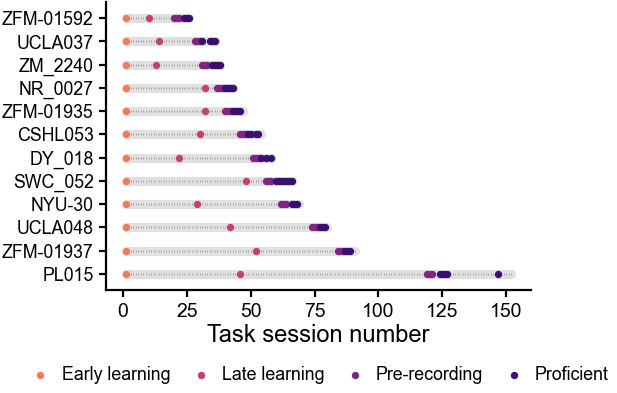

In [4]:
"""
PANEL A -- one row per example mouse: every task session, with the four datasets marked.
Small grey ticks are sessions we simply know happened; the large coloured markers are
the sessions that actually enter the analyses.
"""
def trajectory_panel(ax, mice, marker_size=.5):
    for row, m in enumerate(mice):
        s = TASK.loc[TASK['mouse_name'] == m].sort_values('train_ord')
        ax.plot([1, s['train_ord'].max()], [row, row], '-', color='0.88',
                lw=plt.rcParams['lines.linewidth'] * 2.2, solid_capstyle='round', zorder=1)
        ax.scatter(s['train_ord'], np.full(len(s), row), s=2.0, color='0.62',
                   marker='|', linewidths=0.6, zorder=2)
        mk = MARK.loc[MARK['mouse_name'] == m]
        for tp in ORDER:
            sel = mk.loc[mk['timepoint'] == tp, 'train_ord'].values
            if not len(sel):
                continue
            ax.scatter(sel, np.full(len(sel), row), s=(plt.rcParams['lines.markersize']
                                                       * 0.95 * marker_size) ** 2,
                       color=COLORS[tp], zorder=4, clip_on=False,
                       label=LABELS[tp] if row == 0 else None)
    ax.set_yticks(range(len(mice)))
    ax.set_yticklabels(mice, fontsize=plt.rcParams['font.size'] * 0.8)
    ax.set_ylim(-0.7, len(mice) - 0.3)
    ax.invert_yaxis()
    ax.set_xlabel('Task session number')
    return ax


ps.reapply()
fig, ax = ps.figure('single', scale=.9)
trajectory_panel(ax, EXAMPLES)
# legend BELOW the axes: at lower right it sat on top of the longest mouse's row
ax.legend(fontsize=plt.rcParams['font.size'] * 0.8, ncol=4, frameon=False,
          loc='upper center', bbox_to_anchor=(0.5, -0.22))
# ax.set_title(f'{N_MICE} mice spanning the range of training length',
#              fontsize=plt.rcParams['font.size'] * 0.95)
fig.tight_layout()
ps.savefig(fig, 'timepoints_example_trajectories', svg=True)
plt.show()

wrote figures/timepoints_cohort_overview_poster_13-09-2026.png, figures/timepoints_cohort_overview_poster_13-09-2026.svg


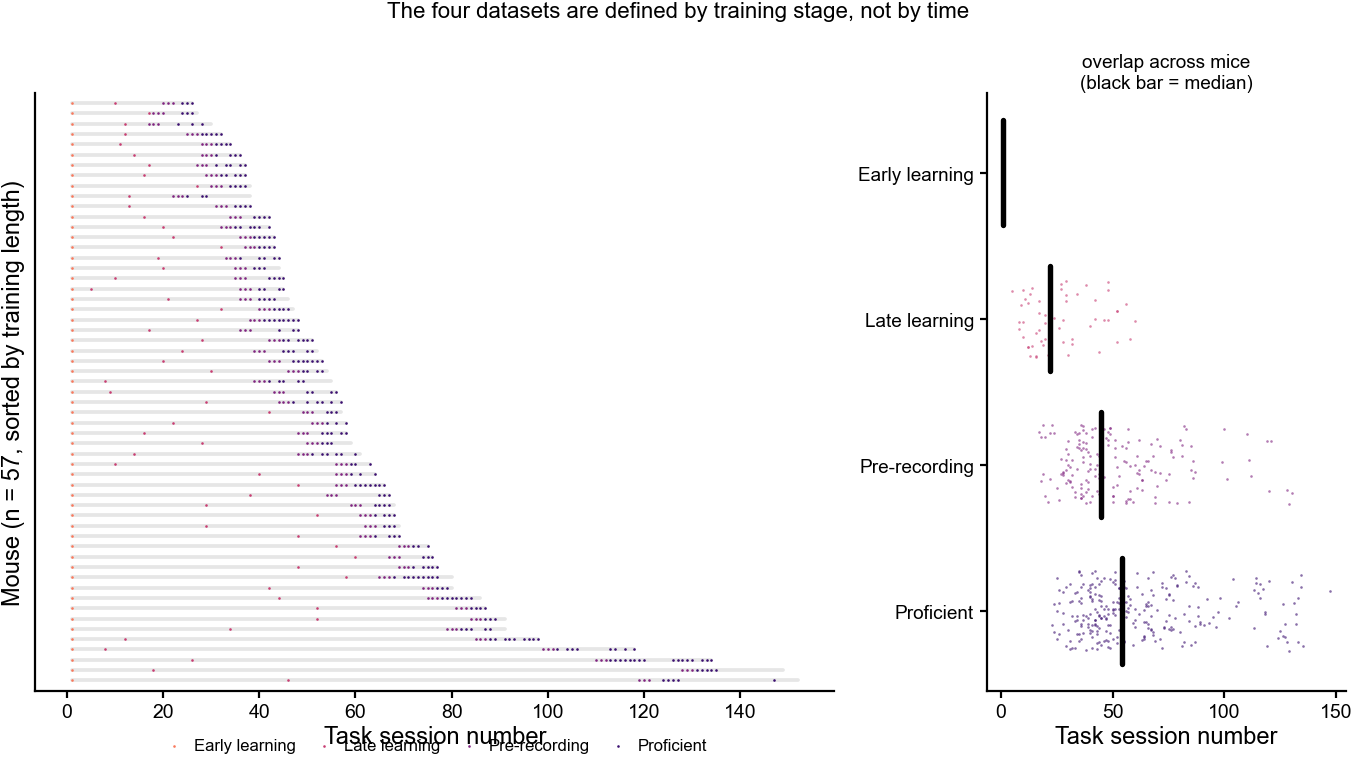

overlap in plain numbers:
  Early learning session   1 -   1  (median 1)
  Late learning  session   5 -  60  (median 22)
  Pre-recording  session  17 - 130  (median 45)
  Proficient     session  23 - 147  (median 54)

28 of 57 Late sessions fall LATER than the earliest Proficient session (session 23).


In [5]:
"""
PANEL B -- the whole cohort, same axis, sorted by training length.
This is the panel that shows the timepoints are stage-defined rather than time-defined:
the coloured bands smear across each other instead of forming four tidy columns.
"""
ps.reapply()
order_mice = list(n_last[COHORT].sort_values().index)
fig, axes = plt.subplots(1, 2, figsize=(ps.SIZES[ps.MODE]['double'][0],
                                        ps.SIZES[ps.MODE]['double'][1] * 1.25),
                         gridspec_kw=dict(width_ratios=[3, 1.35]))

ax = axes[0]
for row, m in enumerate(order_mice):
    s = TASK.loc[TASK['mouse_name'] == m]
    ax.plot([1, s['train_ord'].max()], [row, row], '-', color='0.90',
            lw=plt.rcParams['lines.linewidth'] * 0.9, zorder=1)
    mk = MARK.loc[MARK['mouse_name'] == m]
    for tp in ORDER:
        sel = mk.loc[mk['timepoint'] == tp, 'train_ord'].values
        if len(sel):
            ax.scatter(sel, np.full(len(sel), row), s=3.5, color=COLORS[tp],
                       zorder=3, linewidths=0, label=LABELS[tp] if row == 0 else None)
ax.set_ylim(-1, len(order_mice)); ax.invert_yaxis()
ax.set_ylabel(f'Mouse (n = {len(order_mice)}, sorted by training length)')
ax.set_xlabel('Task session number')
ax.set_yticks([])
ax.legend(fontsize=plt.rcParams['font.size'] * 0.75, ncol=4, frameon=False,
          loc='upper center', bbox_to_anchor=(0.5, -0.06))

ax = axes[1]
for i, tp in enumerate(ORDER):
    v = MARK.loc[MARK.mouse_name.isin(COHORT) & (MARK.timepoint == tp), 'train_ord'].values
    jitter = (np.random.default_rng(i).random(len(v)) - 0.5) * 0.55
    ax.scatter(v, np.full(len(v), i) + jitter, s=3.5, color=COLORS[tp],
               alpha=0.6, linewidths=0)
    ax.plot([np.median(v)] * 2, [i - 0.36, i + 0.36], color='k',
            lw=plt.rcParams['lines.linewidth'] * 1.3, zorder=5)
ax.set_yticks(range(len(ORDER)))
ax.set_yticklabels([LABELS[t] for t in ORDER], fontsize=plt.rcParams['font.size'] * 0.85)
ax.invert_yaxis()
ax.set_xlabel('Task session number')
ax.set_title('overlap across mice\n(black bar = median)',
             fontsize=plt.rcParams['font.size'] * 0.85)

fig.suptitle('The four datasets are defined by training stage, not by time',
             fontsize=plt.rcParams['font.size'])
fig.tight_layout()
ps.savefig(fig, 'timepoints_cohort_overview', svg=True)
plt.show()

print('overlap in plain numbers:')
for tp in ORDER:
    v = MARK.loc[MARK.mouse_name.isin(COHORT) & (MARK.timepoint == tp), 'train_ord']
    print(f'  {LABELS[tp]:14s} session {int(v.min()):3d} - {int(v.max()):3d}  (median {int(v.median())})')
late = MARK.loc[MARK.mouse_name.isin(COHORT) & (MARK.timepoint == "Late"), "train_ord"]
prof = MARK.loc[MARK.mouse_name.isin(COHORT) & (MARK.timepoint == "Proficient"), "train_ord"]
print(f'\n{int((late > prof.min()).sum())} of {len(late)} Late sessions fall LATER than the '
      f'earliest Proficient session (session {int(prof.min())}).')

trials tables: /Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/data/training/training_data
wrote figures/timepoints_learning_curves_poster_13-09-2026.png, figures/timepoints_learning_curves_poster_13-09-2026.svg


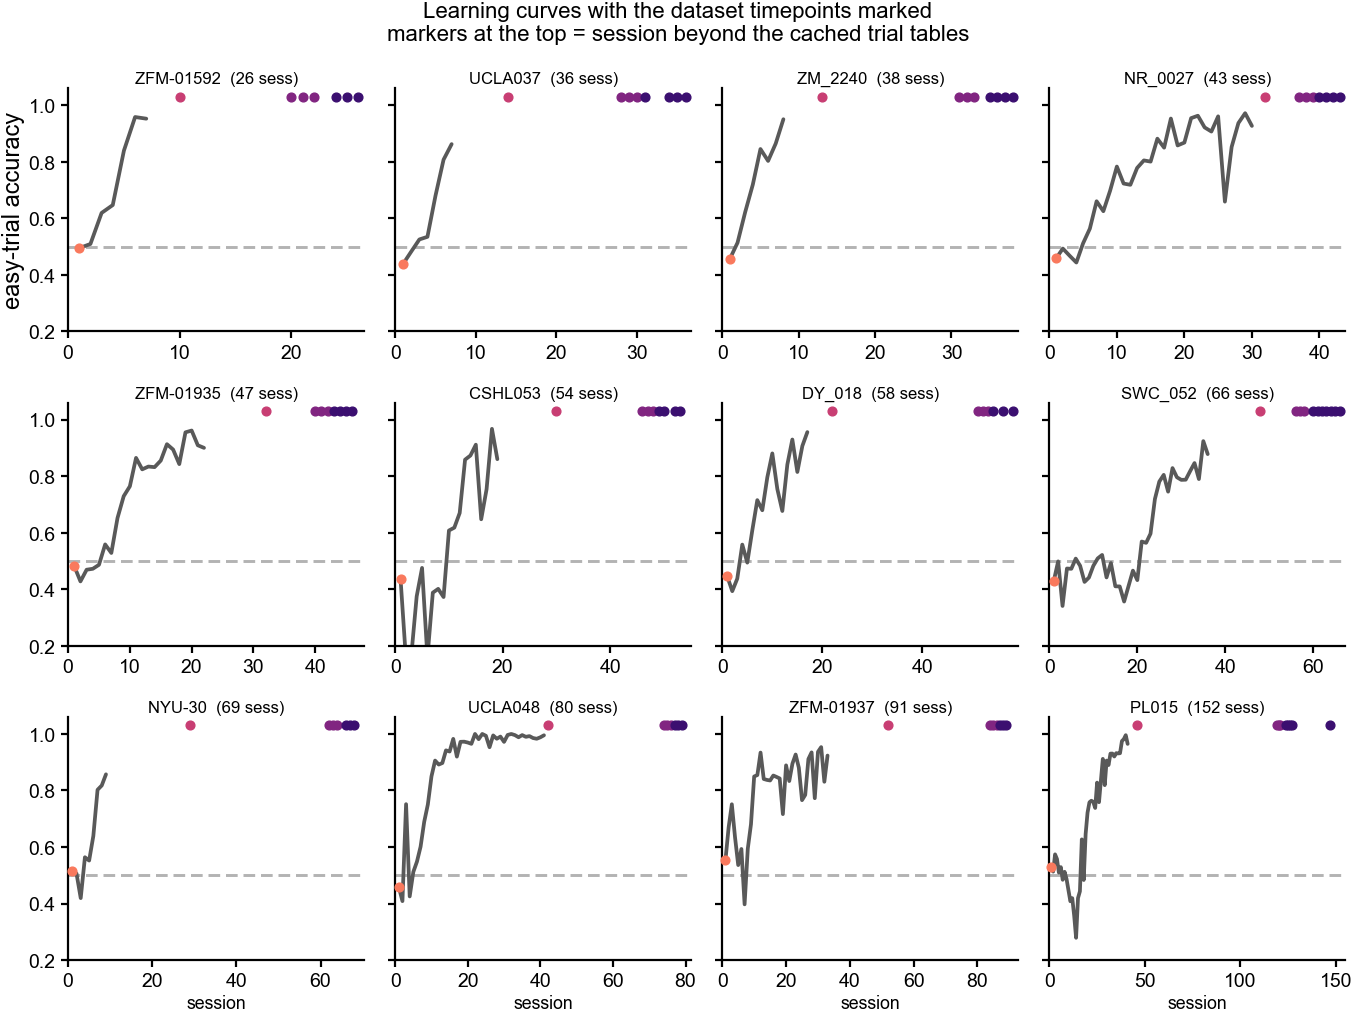

In [6]:
"""
PANEL C -- what the animal was actually doing at those sessions.
Easy-trial accuracy (|contrast| >= 0.5) per session, from the per-mouse trials tables.

WHY THE CURVE STOPS. Those tables cover the basic training protocol only, so the line
ends around the Late marker and Pre-rec / Proficient sit beyond it. That is a property
of the cached data, not of the animal -- the sessions exist, their trial tables are
just not in this folder. Markers past the end of a line are drawn at the top of the
panel rather than silently dropped.

What this panel DOES show: Early sits at or below chance in every animal, which is the
main justification for calling it "early".

What it does NOT show, contrary to what one might expect: where Late falls relative to
saturation. The cached tables stop before the Late session in ALL of these mice, so
every Late marker is drawn at the top rather than on the curve. Establishing that Late
follows saturation would need trial data for the biased sessions, which is not cached
here.
"""
if not SHOW_LEARNING_CURVE:
    print('SHOW_LEARNING_CURVE is False -- skipped')
else:
    import os

    # the per-mouse trials tables: local copy first, Google Drive as the fallback
    _TT = next((d for d in [_root / 'data' / 'training' / 'training_data',
                            pathlib.Path('/Users/ineslaranjeira/Google Drive/O meu disco/'
                                         'CCU/PhD Project/paper-individuality/data/'
                                         'training/training_data (1)')] if d.is_dir()), None)
    assert _TT is not None, 'no training_data directory found'
    print(f'trials tables: {_TT}')

    def session_accuracy(mouse):
        f = os.path.join(str(_TT), f'training_data_trials_{mouse}')
        if not os.path.exists(f):
            return None
        t = pd.read_parquet(f, columns=['session', 'feedbackType',
                                        'contrastLeft', 'contrastRight'])
        t['correct'] = (t['feedbackType'] == 1).astype(float)
        t['absc'] = t[['contrastLeft', 'contrastRight']].fillna(0).max(axis=1)
        acc = (t.loc[t['absc'] >= 0.5].groupby('session')['correct']
               .agg(['mean', 'size']).rename(columns={'mean': 'acc', 'size': 'n'}))
        acc = acc.loc[acc['n'] >= 20]
        o = TASK.loc[TASK['mouse_name'] == mouse].set_index('eid')['train_ord']
        acc['train_ord'] = o.reindex(acc.index).values
        return acc.dropna(subset=['train_ord']).sort_values('train_ord')

    ps.reapply()
    LW = plt.rcParams['lines.linewidth']
    ncol = 4
    nrow = int(np.ceil(len(EXAMPLES) / ncol))
    fig, axes = plt.subplots(nrow, ncol, sharex=False, sharey=True,
                             figsize=(ps.SIZES[ps.MODE]['double'][0],
                                      ps.SIZES[ps.MODE]['double'][1] * 0.55 * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax, m in zip(axes, EXAMPLES):
        a = session_accuracy(m)
        if a is not None and len(a):
            ax.plot(a['train_ord'], a['acc'], '-', color='0.35', lw=LW * 0.9, zorder=2)
        else:
            # SAY SO. Drawing only the markers made an absent trials table look like
            # a finding rather than missing data (this is what NYU-37 did).
            ax.text(0.5, 0.45, 'no cached\ntrial data', transform=ax.transAxes,
                    ha='center', va='center', color='0.55',
                    fontsize=plt.rcParams['font.size'] * 0.8)
        ax.axhline(0.5, ls=(0, (4, 2)), color='0.7', lw=LW * 0.7, zorder=1)
        mk = MARK.loc[MARK['mouse_name'] == m]
        xmax = TASK.loc[TASK['mouse_name'] == m, 'train_ord'].max()
        for tp in ORDER:
            for x in mk.loc[mk['timepoint'] == tp, 'train_ord'].values:
                inside = a is not None and len(a) and x <= a['train_ord'].max()
                y = (np.interp(x, a['train_ord'], a['acc']) if inside else 1.03)
                ax.scatter([x], [y], s=(plt.rcParams['lines.markersize'] * 0.7) ** 2,
                           color=COLORS[tp], zorder=4, clip_on=False)
        ax.set_xlim(0, xmax * 1.02); ax.set_ylim(0.2, 1.06)
        ax.set_title(f'{m}  ({int(xmax)} sess)', fontsize=plt.rcParams['font.size'] * 0.75)
    for ax in axes[len(EXAMPLES):]:
        ax.set_visible(False)
    for ax in axes[:len(EXAMPLES)][-ncol:]:
        ax.set_xlabel('session', fontsize=plt.rcParams['font.size'] * 0.8)
    axes[0].set_ylabel('easy-trial accuracy')
    fig.suptitle('Learning curves with the dataset timepoints marked\n'
                 'markers at the top = session beyond the cached trial tables',
                 fontsize=plt.rcParams['font.size'])
    fig.tight_layout()
    ps.savefig(fig, 'timepoints_learning_curves', svg=True)
    plt.show()

## Reading the figures

**Panel A** — `N_MICE` example animals (default 8), chosen to span the range of training
length rather than picked arbitrarily. Grey ticks are every task session; coloured dots
are the sessions that enter the analyses.

**Panel B** — all 58 mice, sorted by training length, plus the marginal distribution of
each timepoint. This is the panel worth putting in a methods figure: the four datasets
do **not** form tidy columns. Early is pinned at session 1, but Late, Pre-rec and
Proficient smear across each other, because they are defined by *training stage* and
mice differ several-fold in how long a stage takes.

**Panel C** — Early sits at or below chance in every animal, which is what justifies
calling it early. It does **not** show where Late falls relative to saturation: the
cached trial tables cover only the basic training protocol and stop before the Late
session in all of these mice, so every Late marker is drawn at the top of its subplot
rather than on the curve. Showing Late against performance would need trial data for
the biased sessions, which is not cached here.

`PL034` is excluded (`EXCLUDE_MICE`), matching `lda_pred` and
`wheel_velocity_timepoints`: its cached trials table contains a single session, so it
has no curve and its record looks incomplete.

### Parameters

`N_MICE` (8), `SPAN_SELECTION` (span fastest→slowest vs alphabetical), and
`SHOW_LEARNING_CURVE` are at the top of the config cell.

### Provenance of the session axis

`session_ordinals_task.parquet` was built once from ONE (~1 min for 58 mice) and is
cached, so the notebook needs no network. It counts **training, biased and ephys**
sessions and drops habituation — without that filter Early lands at a median ordinal of
4 rather than 1, since habituation sessions precede the first training session.

Proficient placement is 270/340: the remaining recordings belong to mice outside this
57-mouse cohort (58 fetched, minus `PL034`), whose session lists were not fetched.